## Lab - EDA Bivariate Analysis: Diving into Amazon UK Product Insights Part II

**Objective**: Delve into the dynamics of product pricing on Amazon UK to uncover insights that can inform business strategies and decision-making.

**Dataset**: This lab utilizes the [Amazon UK product dataset](https://www.kaggle.com/datasets/asaniczka/uk-optimal-product-price-prediction/)
which provides information on product categories, brands, prices, ratings, and more from from Amazon UK. You'll need to download it to start working with it.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub 
from kagglehub import KaggleDatasetAdapter

In [5]:
# Download latest version
path = kagglehub.dataset_download("asaniczka/uk-optimal-product-price-prediction")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\ASUS\.cache\kagglehub\datasets\asaniczka\uk-optimal-product-price-prediction\versions\3


In [6]:
import os
file_path = os.path.join(path, "amz_uk_price_prediction_dataset.csv")
df = pd.read_csv(file_path)

In [7]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [11]:
df.columns

Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               object 
 2   title              object 
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 151.5+ MB


In [18]:
df["asin"].value_counts()

asin
B083L94P36    7
B08CS1RJYK    7
B07MVP6T9C    7
B0884G1PZ5    7
B08BDG1DR2    7
             ..
B004BW8TYC    1
B0BPMBYBKL    1
B0BV24Z9M4    1
B08NVLFT7M    1
B08P3W9B3T    1
Name: count, Length: 2222742, dtype: int64

To begin with, we can inspect all categorical columns (variables).

In [22]:
df.select_dtypes(include='object').columns

Index(['asin', 'title', 'category'], dtype='object')

Checking all values of the Category categorical variable.

In [ ]:
df["category"].value_counts()

category
Sports & Outdoors                         836265
Beauty                                     19312
Handmade Clothing, Shoes & Accessories     19229
Bath & Body                                19092
Birthday Gifts                             18978
                                           ...  
Alexa Built-In Devices                       107
Motorbike Chassis                            107
Plugs                                        107
Smart Home Security & Lighting               104
Smart Speakers                                54
Name: count, Length: 296, dtype: int64

Checking all values of the isBestSeller categorical variable.

In [20]:
df["isBestSeller"].value_counts()

isBestSeller
False    2435671
True        7980
Name: count, dtype: int64

Checking all numerical columns.

In [24]:
df.select_dtypes(include='number').columns

Index(['uid', 'stars', 'reviews', 'price', 'boughtInLastMonth'], dtype='object')

What follows is a statistical summary of all numerical variables. 

In [21]:
df.describe()

,uid,stars,reviews,price,boughtInLastMonth
count,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06
mean,1.370545e+06,2.152836e+00,4.806278e+02,8.924381e+01,2.589699e+01
std,8.160562e+05,2.194865e+00,5.944124e+03,3.456089e+02,2.404837e+02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.589215e+05,0.000000e+00,0.000000e+00,9.990000e+00,0.000000e+00
50%,1.349029e+06,0.000000e+00,0.000000e+00,1.909000e+01,0.000000e+00
75%,2.060686e+06,4.400000e+00,5.900000e+01,4.599000e+01,0.000000e+00
max,2.828593e+06,5.000000e+00,1.356658e+06,1.000000e+05,5.000000e+04


### Part 1: Analyzing Best-Seller Trends Across Product Categories

**Objective**: Understand the relationship between product categories and their best-seller status.

1. **Crosstab Analysis**:
    - Create a crosstab between the product `category` and the `isBestSeller` status.
    
    - Are there categories where being a best-seller is more prevalent? 
    	
    	*Hint: one option is to calculate the proportion of best-sellers for each category and then sort the categories based on this proportion in descending order.*


2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    - Compute Cramér's V to understand the strength of association between best-seller status and category.

3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

1. **Crosstab Analysis**:
    - Creating a crosstab between the product `category` and the `isBestSeller` status.

In [28]:
pd.crosstab(df['category'], df['isBestSeller']).sort_values(by=True, ascending=False)

isBestSeller,False,True
category,,
Grocery,9008,556
Health & Personal Care,9017,552
Baby,14709,341
Sports & Outdoors,835935,330
Power & Hand Tools,8353,306
...,...,...
Downhill Ski Boots,1284,0
Digital Frames,774,0
Motorbike Chassis,107,0


In [30]:
pd.crosstab(df['category'], df['isBestSeller'], normalize='index') \
    .sort_values(by=True, ascending=False)

isBestSeller,False,True
category,,
Grocery,0.941865,0.058135
Smart Home Security & Lighting,0.942308,0.057692
Health & Personal Care,0.942314,0.057686
Mobile Phone Accessories,0.957529,0.042471
Power & Hand Tools,0.964661,0.035339
...,...,...
"CD, Disc & Tape Players",1.000000,0.000000
General Music-Making Accessories,1.000000,0.000000
Snowboard Boots,1.000000,0.000000


So, the Grocery category is the one with the highest proportion of best sellers (approximately 5.81%), followed by Smart Home Security & Lighting (approximately 5.77%), Health & Personal Care (approximately 5.77%), Mobile Phone Accessories (approximately 4.25%), and Power & Hand Tools (approximately 3.53%). The other categories' proportions in terms of best sellers are significantly lower below that point.

For demonstration purposes, one can check the proportion of best sellers specifically for the Sports & Outdoors category, which happens to be top most listed category.

In [32]:
pd.crosstab(df['category'], df['isBestSeller'], normalize='index') \
    .loc['Sports & Outdoors']

isBestSeller
False    0.999605
True     0.000395
Name: Sports & Outdoors, dtype: float64

2. **Statistical Tests**:
    - Conduct a Chi-square test to determine if the best-seller distribution is independent of the product category.
    - Compute Cramér's V to understand the strength of association between best-seller status and category.

Conducting the Chi-square test first to determine whether the best-seller distribution is independent of the product category.

In [36]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['category'], df['isBestSeller'])

_, p, _, _ = chi2_contingency(contingency_table)

print(p)

0.0


Conducting the Cramérs-V test to determine the strenght of the association between best status and category.

In [37]:
from scipy.stats.contingency import association

cramers_v = association(contingency_table, method='cramer')

print(cramers_v)

0.1222829439760564


So the conclusion is that the Chi-Square did hint into a potential dependency between the best status and the category variables, but the Cramérs-V test allows us to go even further and conclude that the effect is actually small in the sense that categories do not strongly determine the best seller status.

In other words, there is a statistically significant relationship between category and bestseller status, but the strength of this association is weak, suggesting that category alone is not a strong driver of bestseller status.

3. **Visualizations**:
	- Visualize the relationship between product categories and the best-seller status using a stacked bar chart.

Here is the first attempt at plotting a stacked bar chart between the category and the isbestseller categories.

<Axes: xlabel='category'>

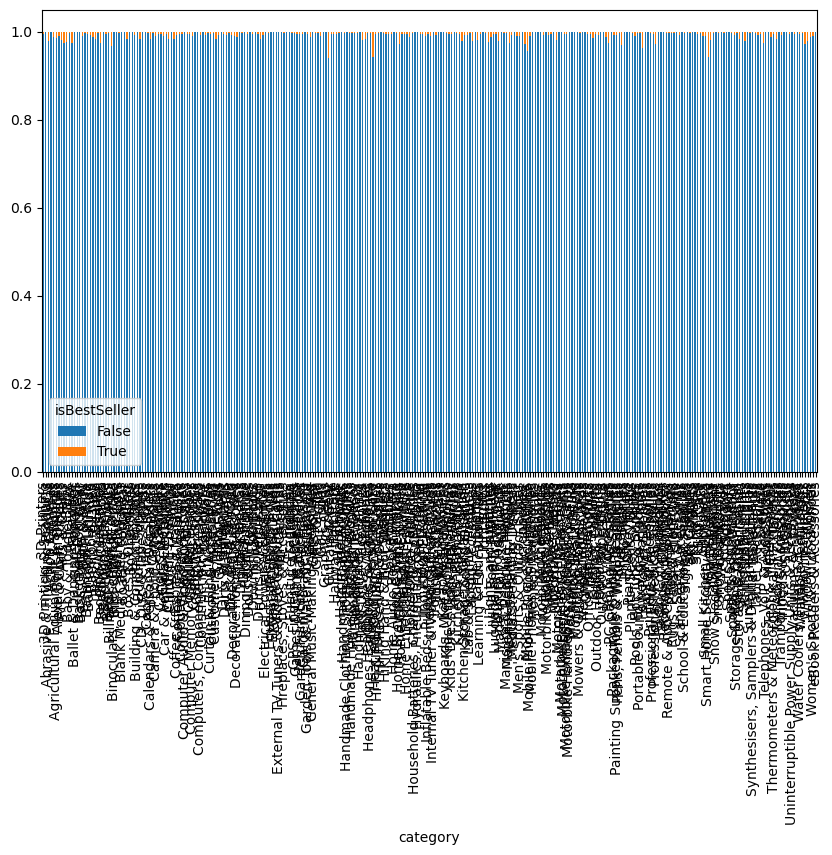

In [38]:
pd.crosstab(df['category'], df['isBestSeller'], normalize='index') \
    .plot(kind='bar', stacked=True, figsize=(10,6))

We can see that things quickly get confusing, given the high number of categories (specifically the unique values inside category). Therefore, we can limit the number of categories to, say, 20, for better visualisation. As such:

In [40]:
top_categories = df['category'].value_counts().head(20).index
top_categories

Index(['Sports & Outdoors', 'Beauty', 'Handmade Clothing, Shoes & Accessories',
       'Bath & Body', 'Birthday Gifts', 'Manicure & Pedicure Products',
       'Skin Care', 'Make-up', 'Hair Care', 'Fragrances', 'Handmade Gifts',
       'Handmade Home Décor', 'Luggage and travel gear', 'Handmade Jewellery',
       'Handmade Artwork', 'Women', 'Handmade Home & Kitchen Products',
       'Handmade Kitchen & Dining', 'Men', 'Baby'],
      dtype='object', name='category')

<Axes: xlabel='category'>

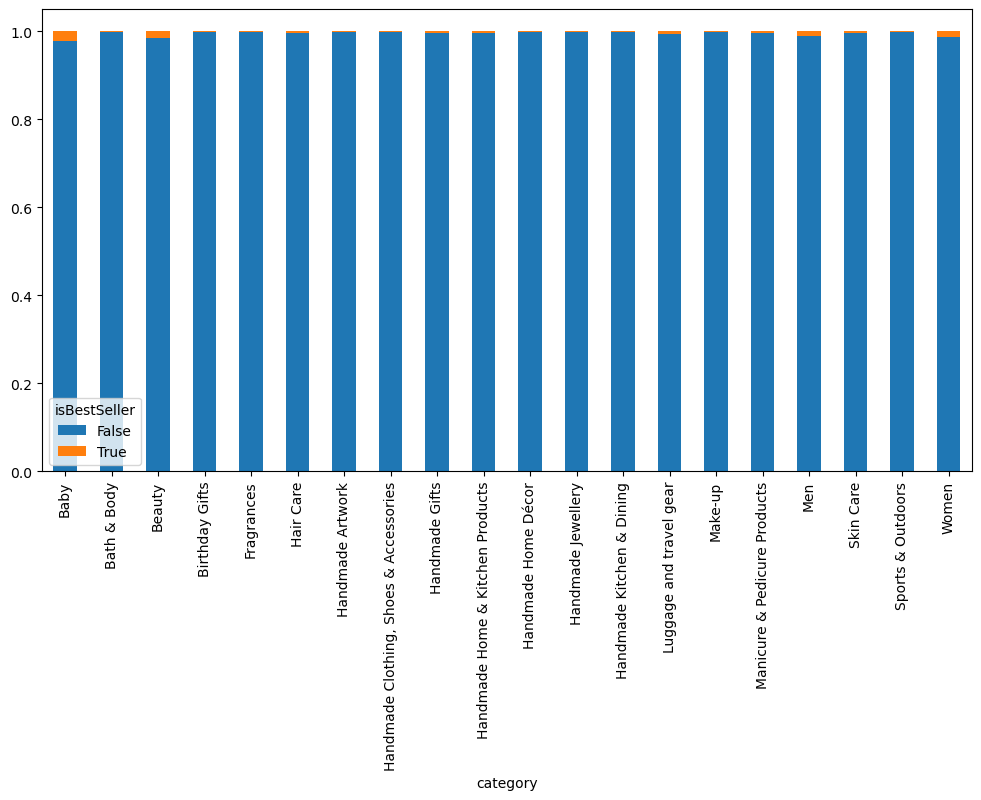

In [41]:
top_categories = df['category'].value_counts().head(20).index

pd.crosstab(df[df['category'].isin(top_categories)]['category'],
            df[df['category'].isin(top_categories)]['isBestSeller'],
            normalize='index') \
    .plot(kind='bar', stacked=True, figsize=(12,6))

So, from the stacked bar chart, we also see that the bestseller status is rare across categories, and no category shows a strong dominance, which is consistent with the weak association found statistically in Part 1.2.

### Part 2: Exploring Product Prices and Ratings Across Categories and Brands

**Objective**: Investigate how different product categories influence product prices.

0. **Preliminary Step: Remove outliers in product prices.**

	For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
	
	*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*

1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    - Which product category tends to have the highest median price? Don't filter here by top categories.

2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
    - Which product category commands the highest average price? Don't filter here by top categories.

3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
    - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

0. **Preliminary Step: Remove outliers in product prices.**

	For this purpose, we can use the IQR (Interquartile Range) method. Products priced below the first quartile minus 1.5 times the IQR or above the third quartile plus 1.5 times the IQR will be considered outliers and removed from the dataset. The next steps will be done with the dataframe without outliers.
	
	*Hint: you can check the last Check For Understanding at the end of the lesson EDA Bivariate Analysis for a hint on how to do this.*

First of all, we determine the Inter-quantile Range of values (IQR), given by the difference between Q1 and Q3. Hence:

In [ ]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR    # lower bound of the IQR
upper_bound = Q3 + 1.5 * IQR    # upper bound of the IQR

The next step is to remove potential outliers, which could distort the analysis by pulling averages, spreads and visuals, thereby making visualisations harder to interpret. Another downside of outliers is that these have a compression effect on the data, which could contribute to compressing the remainder of the data set and the true data pattern as a result.

So the main purpose of this preliminary step is to see the real structure of the majority of the data.

Thus:

In [43]:
df_outliers_removed = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

1. **Violin Plots**:
    - Use a violin plot to visualize the distribution of `price` across different product `categories`. Filter out the top 20 categories based on count for better visualization.
    - Which product category tends to have the highest median price? Don't filter here by top categories.

Filtering out the top 20 categories, first.

In [46]:
top_20_categories = df['category'].value_counts().head(20).index

Now applying this data subset to the data set with outliers removed.

In [47]:
df_top_20 = df_outliers_removed[df_outliers_removed['category'].isin(top_20_categories)]

The violin plot then becomes:

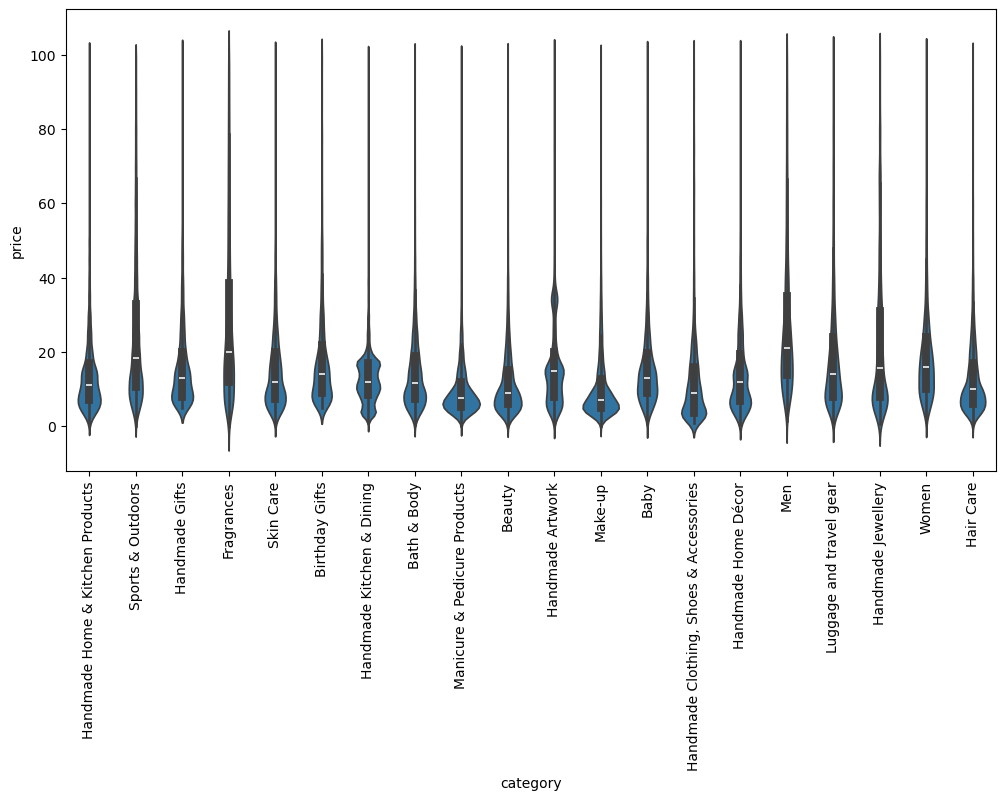

In [51]:
plt.figure(figsize=(12,6))
sns.violinplot(data=df_top_20, x='category', y='price')
plt.xticks(rotation=90)
plt.show()

By examining the set of violin plots there two of the product categories (Fragrances and Men) whose means appear to be the highest. For better visualisation: 

<Axes: xlabel='category', ylabel='price'>

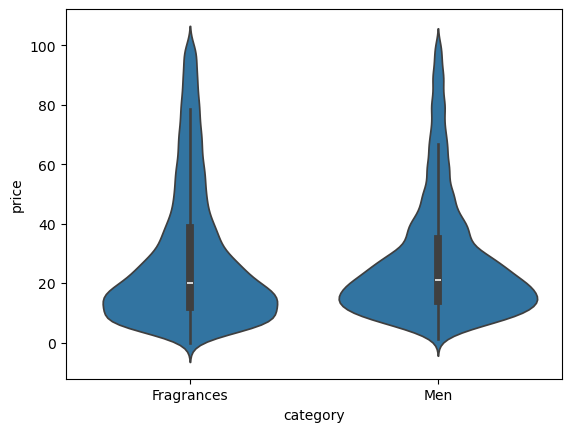

In [53]:
categories_selection = ['Fragrances', 'Men']
df_compare = df_outliers_removed[df_outliers_removed['category'].isin(categories_selection)]
sns.violinplot(data=df_compare, x='category', y='price', inner='box')

Comparing means for these two categories yields:

In [54]:
df_compare.groupby('category')['price'].mean()

category
Fragrances    28.544912
Men           27.461174
Name: price, dtype: float64

Performing a sanity check to ensure we picked the 2 top categories correctly:

In [55]:
df_top_20.groupby('category')['price'].mean().sort_values(ascending=False)

category
Fragrances                                28.544912
Men                                       27.461174
Sports & Outdoors                         25.172065
Handmade Jewellery                        22.801007
Women                                     20.408735
Luggage and travel gear                   19.718228
Birthday Gifts                            18.600195
Handmade Artwork                          17.461758
Handmade Gifts                            17.395112
Baby                                      16.389799
Skin Care                                 15.654722
Handmade Home Décor                       15.413691
Bath & Body                               14.678683
Handmade Home & Kitchen Products          14.079947
Hair Care                                 13.461408
Handmade Kitchen & Dining                 13.119728
Handmade Clothing, Shoes & Accessories    12.958639
Beauty                                    12.523480
Make-up                                   10.612918
Man

In [72]:
df_outliers_removed.groupby('category')['price'].median().sort_values(ascending=False)

category
Desktop PCs              74.00
Boxing Shoes             69.79
Tablets                  69.00
Graphics Cards           68.54
Motherboards             67.92
                         ...  
Adapters                  7.05
Make-up                   7.00
Signs & Plaques           6.99
Arts & Crafts             5.99
Office Paper Products     4.37
Name: price, Length: 296, dtype: float64

In [73]:
df['category'].value_counts().loc['Desktop PCs']

np.int64(7395)

In [75]:
df['category'].value_counts().loc['Boxing Shoes']

np.int64(4074)

In [74]:
df['category'].value_counts().loc['Fragrances']

np.int64(18564)

The conclusion is that category Desktop PCs has the highest median price overall. However, it has a relatively low number of observations compared to Fragrances. Among the most frequent categories (top 20), the Fragrances product category shows the highest median price.

2. **Bar Charts**:
    - Create a bar chart comparing the average price of products for the top 10 product categories (based on count).
    - Which product category commands the highest average price? Don't filter here by top categories.

To access the average price of the top 10 product categories based on count, we calculate: 

In [57]:
top10_mean = df_top_20.groupby('category')['price'].mean() \
    .sort_values(ascending=False).head(10)

Sorting by descending order:

In [58]:
top10_mean = df_top_20.groupby('category')['price'].mean() \
    .sort_values(ascending=False).head(10)

And for the respective bar chart, we get:

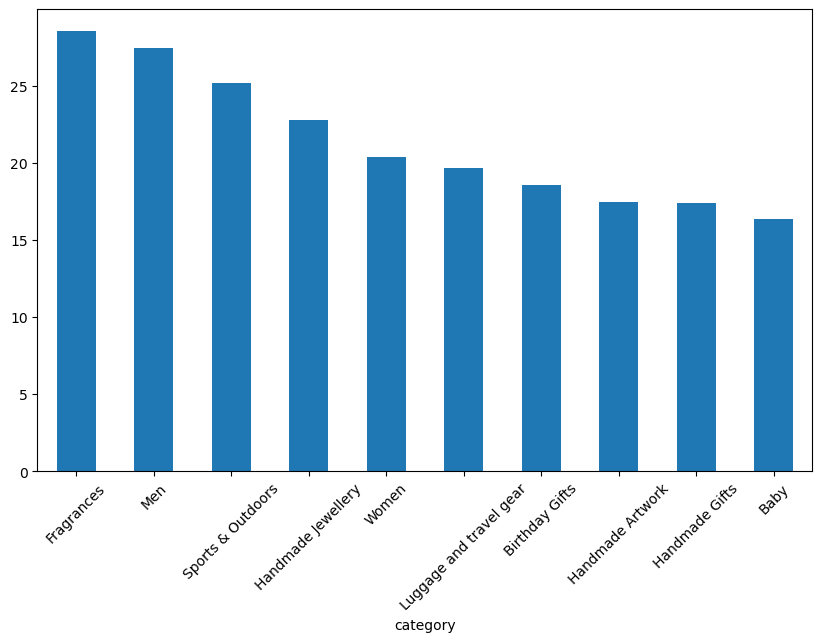

In [59]:
top10_mean.plot(kind='bar', figsize=(10,6))
plt.xticks(rotation=45)
plt.show()

To detect the true highest price, however, we perform the following:

In [76]:
df_outliers_removed.groupby('category')['price'].mean() \
    .sort_values(ascending=False)

category
Motherboards             68.772432
Boxing Shoes             67.417803
Desktop PCs              66.915562
Tablets                  66.552971
Graphics Cards           65.103509
                           ...    
Bedding Accessories       8.835220
Adapters                  8.750197
Signs & Plaques           8.210513
Arts & Crafts             8.006540
Office Paper Products     6.876369
Name: price, Length: 296, dtype: float64

In [77]:
df['category'].value_counts().loc['Motherboards']

np.int64(259)

In [78]:
df['category'].value_counts().loc['Fragrances']

np.int64(18564)

In [79]:
df_outliers_removed.groupby('category')['price'].mean().loc[['Motherboards', 'Fragrances']]

category
Motherboards    68.772432
Fragrances      28.544912
Name: price, dtype: float64

The category with the highest average price overall is Motherboards, with a substantially higher mean. Although it has fewer observations (~200) compared to more frequent categories (~10,000+), the sample size is still sufficient to consider this result meaningful. However, categories with larger sample sizes (e.g.: Fragrances) provide more stable estimates.

The bar chart reveals that the Frangrances category has the highest average price among the top 10 specifically

3. **Box Plots**:
    - Visualize the distribution of product `ratings` based on their `category` using side-by-side box plots. Filter out the top 10 categories based on count for better visualization.
    - Which category tends to receive the highest median rating from customers? Don't filter here by top categories.

The first step is to filter out the top 10 categories based on count to enhance visualisation. Once again, any outliers are preliminary removed.

In [61]:
top10 = df['category'].value_counts().head(10).index

df_top10 = df_outliers_removed[df_outliers_removed['category'].isin(top10)]

Now we plot:

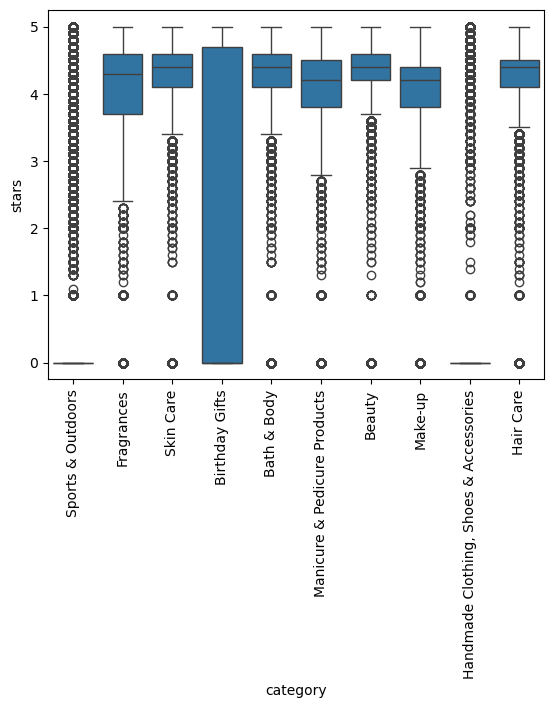

In [67]:
sns.boxplot(data=df_top10, x='category', y='stars')
plt.xticks(rotation=90)
plt.show()

To ensure a more complete and strict numerical analysis is performed, we can sort median values of the data set with outliers removed in the following way (for the entire data set with outliers removed).

In [66]:
df_outliers_removed.groupby('category')['stars'].median().sort_values(ascending=False)

category
Computer Memory                 4.7
Building & Construction Toys    4.6
Office Paper Products           4.6
Luxury Food & Drink             4.6
Kids' Play Figures              4.6
                               ... 
Hockey Shoes                    0.0
Hi-Fi Receivers & Separates     0.0
Handmade Kitchen & Dining       0.0
Handmade Jewellery              0.0
eBook Readers & Accessories     0.0
Name: stars, Length: 296, dtype: float64

Although the Computer Memory category shows the highest median rating overall, it likely contains few observations, making this result less reliable compared to more populated categories (could be due to either a small sample effect ot niche/premium effect).

Regardless, we will refocus our attention onto the top 10 categories and perform a numerical analysis in a descending order, given that the graphical representation is not verya clear in terms of having certain medians distinguished from one another and therefore compared.

Thus:

In [71]:
df_top10.groupby('category')['stars'].median().sort_values(ascending=False)


category
Bath & Body                               4.4
Beauty                                    4.4
Hair Care                                 4.4
Skin Care                                 4.4
Fragrances                                4.3
Make-up                                   4.2
Manicure & Pedicure Products              4.2
Birthday Gifts                            0.0
Handmade Clothing, Shoes & Accessories    0.0
Sports & Outdoors                         0.0
Name: stars, dtype: float64

The observation is that the Bath & Body, Beauty, Hair Care and Skin Care categories tend to receive the highest median rating from customers. In fact their medians are the same, at 4.4.

In conclusion, the category with the highest median rating overall is Computer Memory. However, it has a relatively low number of observations, making this result less reliable. Among the more frequent categories, Bath & Body, Beauty, Hair Care and Skin Care show the highest median rating.

### Part 3: Investigating the Interplay Between Product Prices and Ratings

**Objective**: Analyze how product ratings (`stars`) correlate with product prices.

1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.
    - Is there a significant correlation between product price and its rating?
	
2. **Visualizations**:
    - Use a scatter plot to visualize the relationship between product rating and price. What patterns can you observe?
    - Use a correlation heatmap to visualize correlations between all numerical variables.
    - Examine if product prices typically follow a normal distribution using a QQ plot. 

---

**Submission**: Submit a Jupyter Notebook which contains code and a business-centric report summarizing your findings. 

**Bonus**: 

- Do the same analysis without taking out the outliers. What are your insights?

1. **Correlation Coefficients**:
    - Calculate the correlation coefficient between `price` and `stars`.
    - Is there a significant correlation between product price and its rating?

In [80]:
df_outliers_removed[['price', 'stars']].corr(method='pearson')

,price,stars
price,1.000000,-0.077673
stars,-0.077673,1.000000


In [82]:
df_outliers_removed[['price', 'stars']].corr(method='spearman')

,price,stars
price,1.000000,-0.066797
stars,-0.066797,1.000000
